In [55]:
import os
import gzip
import itertools
import pathlib
from collections import namedtuple
import importlib
import pickle
import subprocess

import numpy as np
from pandas import DataFrame
import matplotlib.pyplot as plt
import matplotlib.patches as patches
%matplotlib inline
plt.rcParams['figure.figsize'] = [16.5, 5]
plt.rcParams['font.size'] = 12
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

In [83]:
Summary = namedtuple("Summary", "trid A B C D is_consistent mean_purity mean_len mean_gc distinct_alleles")

with open("output/summary.pkl", "rb") as file:
    tr_summaries = pickle.load(file)

In [84]:
len(tr_summaries)

650024

In [81]:
tr_summaries[100]

Summary(trid='chr10_100335879_100335903_trsolve_T', A='TTTTTTTTTTTTTTTTTTTTTTTT', B='TTTTTTTTTTTTTTTTTTTTTTTT', C='TTTTTTTTTTTTTTTTTTTTTTTTT', D='TTTTTTTTTTTTTTTTTTTTTTTTT', is_consistent=False, mean_purity=1.0, mean_len=24.4, mean_gc=0.0, distinct_alleles=3)

In [4]:
mean_allele_lens = []
trs_by_motif = [0 for motif in range(0, 5)]
purities_by_motif = [[] for motif in range(0, 5)]
num_composite = 0
simple_mcs = []
composite_mcs = []
for summary in tr_summaries:
    chrom, start, end, source, motifs = summary.trid.split("_")
    mean_allele_lens.append(min(summary.mean_len, 500))
    trs_by_motif[num_motifs - 1] += 1
    motifs = motifs.split("-")
    num_motifs = len(motifs)
    if num_motifs > 1:
        num_composite += 1
        composite_mcs.append(summary.mean_len)
    else:
        simple_mcs.append(summary.mean_len)
        
    purity = summary.mean_purity
    purities_by_motif[num_motifs - 1].append(purity)

trs_by_motif = [count / sum(trs_by_motif) for count in trs_by_motif]

fig, (ax0, ax1, ax2) = plt.subplots(ncols=3, nrows=1, figsize=(10, 3))

ax0.hist(mean_allele_lens, bins=100)
ax0.set_xlabel("Mean allele length (bps)")
ax0.set_xticks([0, 100, 200, 300, 400, 500])
ax0.set_ylabel("TR count")
ax1.bar([1, 2, 3, 4, 5], trs_by_motif)
ax1.set_xticks([1, 2, 3, 4, 5])
ax1.set_xlabel("Number of distinct motifs")
ax1.set_ylabel("TR fraction")
ax2.boxplot(purities_by_motif)
ax2.set_xlabel("Number of distinct motifs")
ax2.set_ylabel("Mean allele purity")

plt.savefig("output/summary_figure/panels_a-c.pdf");

NameError: name 'num_motifs' is not defined

In [300]:
len([mean_len for mean_len in mean_allele_lens if mean_len > 100]) / 655692

0.10272200972407777

In [301]:
num_composite / 655692

0.2598003330832159

In [302]:
np.mean(simple_mcs)

33.91069112767327

In [303]:
np.mean(composite_mcs)

118.37159595888438

In [44]:
def get_motif_len(trid):
    chrom, start, end, source, motifs = trid.split("_")
    motifs = motifs.split("-")
    min_len = min(len(motif) for motif in motifs)
    return min_len

In [77]:
cons_by_len = {x : {"cons": 0, "total" : 0} for x in range(0, 1000 + 1, 50)}
cons_by_motif = {x : {"cons": 0, "total" : 0} for x in range(1, 20 + 1)}
cons_by_purity = {x : {"cons": 0, "total" : 0} for x in range(50, 100 + 1)}

for summary in tr_summaries:
    #print(summary)
    mean_len = min(50 * round(summary.mean_len / 50), 1000)
    motif_len = min(get_motif_len(summary.trid), 20)
    purity = round(100 * summary.mean_purity)
    if summary.is_consistent:
        cons_by_len[mean_len]["cons"] += 1
        cons_by_motif[motif_len]["cons"] += 1
        cons_by_purity[purity]["cons"] += 1
    cons_by_motif[motif_len]["total"] += 1
    cons_by_len[mean_len]["total"] += 1
    cons_by_purity[purity]["total"] += 1

print(cons_by_purity)

{50: {'cons': 2018, 'total': 2327}, 51: {'cons': 3468, 'total': 4130}, 52: {'cons': 3519, 'total': 4189}, 53: {'cons': 3383, 'total': 4043}, 54: {'cons': 3274, 'total': 3918}, 55: {'cons': 3406, 'total': 4152}, 56: {'cons': 3236, 'total': 3926}, 57: {'cons': 3619, 'total': 4327}, 58: {'cons': 3183, 'total': 3878}, 59: {'cons': 2805, 'total': 3377}, 60: {'cons': 3348, 'total': 4004}, 61: {'cons': 2957, 'total': 3538}, 62: {'cons': 3350, 'total': 3964}, 63: {'cons': 2786, 'total': 3291}, 64: {'cons': 3199, 'total': 3749}, 65: {'cons': 3045, 'total': 3599}, 66: {'cons': 3556, 'total': 4049}, 67: {'cons': 3185, 'total': 3704}, 68: {'cons': 4474, 'total': 5033}, 69: {'cons': 4219, 'total': 4757}, 70: {'cons': 5150, 'total': 5795}, 71: {'cons': 4432, 'total': 5003}, 72: {'cons': 5650, 'total': 6312}, 73: {'cons': 5400, 'total': 6051}, 74: {'cons': 7473, 'total': 8257}, 75: {'cons': 6835, 'total': 7622}, 76: {'cons': 8850, 'total': 9727}, 77: {'cons': 9234, 'total': 10199}, 78: {'cons': 10419

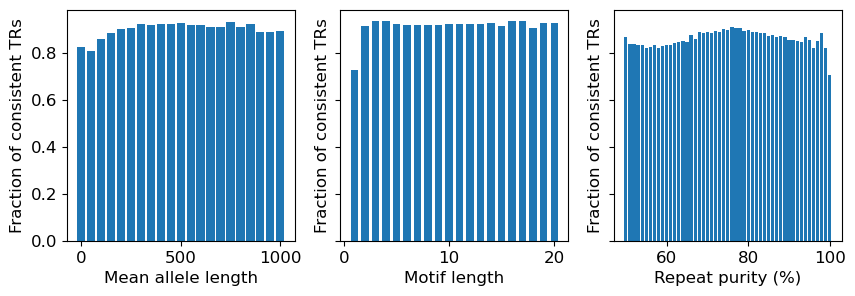

In [307]:
def plot_bars(ax, x_by_y, title_x, title_y, width):
    xs = sorted(x_by_y)
    ys = [x_by_y[x]["cons"] / x_by_y[x]["total"] for x in xs]
    ax.bar(xs, ys, width=width)
    ax.set_xlabel(title_x)
    ax.set_ylabel(title_y)


fig, (ax0, ax1, ax2) = plt.subplots(ncols=3, nrows=1, figsize=(10, 3), sharey=True)

plot_bars(ax0, cons_by_len, "Mean allele length", "Fraction of consistent TRs", 42)
plot_bars(ax1, cons_by_motif, "Motif length", "Fraction of consistent TRs", 0.7)
plot_bars(ax2, cons_by_purity, "Repeat purity (%)", "Fraction of consistent TRs", 0.8)
plt.savefig("output/summary_figure/panels_d-f.pdf");

Text(0, 0.5, 'TR count')

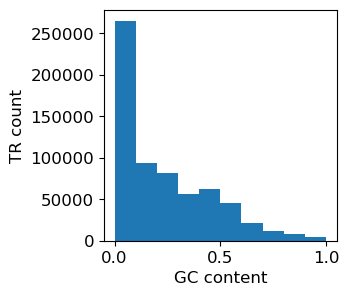

In [323]:
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(3, 3), sharey=True)

all_gs = [s.mean_gc for s in tr_summaries]

#for summary in tr_summaries:
#    print(summary)
#    break

ax.hist(all_gs, bins=10)
ax.set_xlabel("GC content")
ax.set_ylabel("TR count")

In [321]:
sum([s.mean_gc < 0.1 for s in tr_summaries]) / len(tr_summaries)

0.4081187771528436

In [126]:
from collections import Counter

In [240]:
signatures = []

for summary in tr_summaries:
    chrom, start, end, source, motifs = summary.trid.split("_")
    motifs = motifs.split("-")
    if len(motifs) != 6:
        continue
    if summary.A == None:
        continue
    a_sig = [summary.A.count(m) for m in motifs]
    if sum(a_sig) == 0:
        continue
    a_sig = [10 * round((100 * count / sum(a_sig)) / 10) for count in a_sig]
    signatures.append(tuple(sorted(a_sig)))
    #break

In [241]:
sorted(list(Counter(signatures).items()), key=lambda rec: rec[1])

[]

In [242]:
20 * round(51 / 20)

60

/pbi/flash/edolzhenko/2024/Q2/PlatinumPedigree/pipelines/tandem-repeats


## Attempt logistic regression

In [60]:
motif_counts = []

with gzip.open("/pbi/flash/tmokveld/data/AWS_sync/PB_TRs/TRGT/GRCh38_v1.0_50bp_merge/493ef25/2216_DM_GRCh38_50bp_merge.sorted.vcf.gz", "rb") as file:
    for line in file:
        line = line.decode()
        if line[0] == "#":
            continue
        motifs = line.split()[7].split(";")[2].replace("MOTIFS=", "")
        motifs = motifs.split(",")
        motif_counts.append(len(motifs))

In [62]:
from collections import Counter

motif_counts = dict(Counter(motif_counts))

In [71]:
total = sum(motif_counts.values())

for motif_count, num_trs in motif_counts.items():
    print(motif_count, num_trs)

3 222706
1 6520496
2 915170
4 54506
5 9852


## Motif figure for Zev

In [345]:
all_motifs = []
for summary in tr_summaries:
    if not summary.is_consistent:
        continue
    chrom, start, end, source, motifs = summary.trid.split("_")
    motifs = motifs.split("-")
    all_motifs.extend(motifs)

In [346]:
motif_counts = list(Counter(all_motifs).items())
motif_counts.sort(key=lambda rec: rec[1], reverse=True)

In [352]:
motif_counts[:50]

[('T', 115046),
 ('A', 112885),
 ('AC', 23895),
 ('TG', 21711),
 ('AT', 18405),
 ('TA', 17008),
 ('GT', 13215),
 ('CA', 10870),
 ('TC', 8668),
 ('AG', 7680),
 ('AAAT', 6788),
 ('TTTA', 5087),
 ('GA', 5041),
 ('AAAC', 4217),
 ('CT', 4129),
 ('TTTG', 3657),
 ('AAT', 3627),
 ('TTA', 3084),
 ('AAAG', 2887),
 ('TTTC', 2856),
 ('ATTT', 2719),
 ('TTG', 2694),
 ('TTAT', 2419),
 ('AAC', 2268),
 ('TATT', 2260),
 ('AATA', 2209),
 ('C', 2160),
 ('ATT', 2081),
 ('G', 2040),
 ('TAAA', 1944),
 ('TTCC', 1824),
 ('AAAAT', 1751),
 ('AAAAC', 1730),
 ('ATA', 1709),
 ('AAGG', 1675),
 ('TTTTG', 1615),
 ('ATAA', 1466),
 ('GAAA', 1465),
 ('CTTT', 1465),
 ('TAT', 1428),
 ('AAGA', 1373),
 ('TTCT', 1366),
 ('CCTT', 1349),
 ('GAAG', 1347),
 ('TTTTA', 1339),
 ('AGAA', 1304),
 ('TATC', 1304),
 ('TCTT', 1268),
 ('AGGG', 1181),
 ('TAA', 1179)]

In [26]:
struct_by_len = {}
purities_by_len = {}

for summary in tr_summaries:
    if not summary.is_consistent:
        continue
    chrom, start, end, source, motifs = summary.trid.split("_")
    motifs = motifs.split("-")

    length = 25 * round(summary.mean_len / 25)
    length = min(length, 1000)

    if length not in struct_by_len:
        struct_by_len[length] = {"total": 0, "homs": 0, "dinucs": 0, "other_simple": 0, "complex": 0}
        purities_by_len[length] = []
    struct_by_len[length]["total"] += 1
    purities_by_len[length].append(summary.mean_purity)

    if len(motifs) == 1 and len(motifs[0]) == 1:
        struct_by_len[length]["homs"] += 1
    elif len(motifs) == 1 and len(motifs[0]) == 2:
        struct_by_len[length]["dinucs"] += 1
    elif len(motifs) == 1:
        struct_by_len[length]["other_simple"] += 1
    else:
        struct_by_len[length]["complex"] += 1

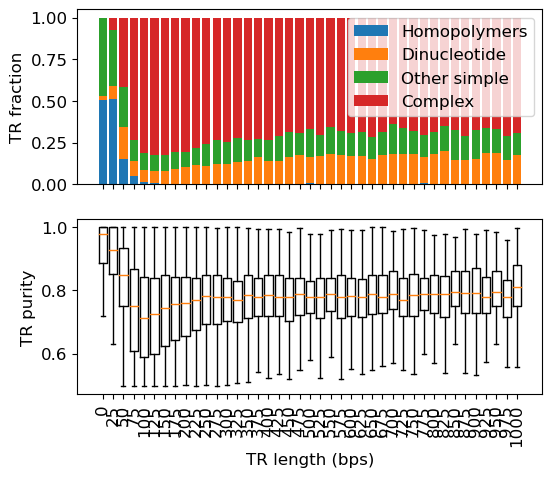

In [28]:
fig, (ax0, ax1) = plt.subplots(ncols=1, nrows=2, figsize=(6, 5), sharex=True)

xs = sorted(struct_by_len)

hom_ys = np.array([struct_by_len[x]["homs"] / struct_by_len[x]["total"] for x in xs])
ax0.bar(xs, hom_ys, width=20, label="Homopolymers")

dinuc_ys = np.array([struct_by_len[x]["dinucs"] / struct_by_len[x]["total"] for x in xs])
ax0.bar(xs, dinuc_ys, width=20, bottom=hom_ys, label="Dinucleotide")

simple_ys = np.array([struct_by_len[x]["other_simple"] / struct_by_len[x]["total"] for x in xs])
ax0.bar(xs, simple_ys, width=20, bottom=hom_ys + dinuc_ys, label="Other simple")

complex_ys = np.array([struct_by_len[x]["complex"] / struct_by_len[x]["total"] for x in xs])
ax0.bar(xs, complex_ys, width=20, bottom=hom_ys + dinuc_ys + simple_ys, label="Complex")
ax0.set_ylabel("TR fraction")
ax0.legend()

purity_vals = [purities_by_len[x] for x in xs]
ax1.boxplot(purity_vals, positions=xs, widths=20, showfliers=False)
ax1.tick_params(axis='x', labelrotation=90)
ax1.set_xlabel("TR length (bps)")
ax1.set_ylabel("TR purity")
plt.savefig("struc_purity_by_len.pdf")

In [78]:
num_examples = 0

for summary in tr_summaries:
    if not summary.is_consistent:
        continue
    chrom, start, end, source, motifs = summary.trid.split("_")
    motifs = motifs.split("-")

    length = 25 * round(summary.mean_len / 25)
    length = min(length, 1000)

    if len(motifs) == 2 and length == 150 and all([len(m) < 10 for m in motifs]):
        print(summary.trid)
        num_examples += 1

        if num_examples == 10:
            break

chr10_100087862_100088018_trsolve_CCTAGA-GA
chr10_100654311_100654453_trsolve_CCCCAC-TC
chr10_101014671_101014815_trsolve_CA-TGCT
chr10_103760521_103760661_trsolve_ACTGTACT-AT
chr10_106241366_106241531_trsolve_AT-AC
chr10_106646884_106647042_trsolve_GT-AT
chr10_107027012_107027162_trsolve_TA-AATGG
chr10_107602866_107603019_trsolve_TCT-CCTCCC
chr10_107799401_107799562_trsolve_CA-TA
chr10_108045727_108045868_trsolve_AT-AC


In [79]:
def plot_trvz(trid):
    vcf = "/pbi/flash/tmokveld/data/AWS_sync/PB_TRs/TRGT/GRCh38_v1.0_50bp_merge/493ef25/2188_DM_GRCh38_50bp_merge.sorted.vcf.gz"
    bam = "/pbi/flash/tmokveld/data/AWS_sync/PB_TRs/TRGT/GRCh38_v1.0_50bp_merge/493ef25/2188_DM_GRCh38_50bp_merge.spanning.sorted.bam"
    catalog = "/pbi/flash/tmokveld/data/bed/repeat_catalog/trsolve/50bp_merge/human_GRCh38_no_alt_analysis_set.palladium-v1.0.trgt.bed"
    subprocess.run(["/home/edolzhenko/flash/2024/Q2/trgt-v0.9.0/trvz/target/x86_64-unknown-linux-gnu/release/trvz-v0.9.0-linux_x86_64",
                    "--genome", "/home/edolzhenko/common/hg38/hg38.fa",
                    "--repeats", catalog,
                    "--vcf", vcf, "--spanning-reads", bam, "--repeat-id", trid,
                    "--image", f"output/plots/{trid}.allele.svg",
                    "--plot-type", "allele",
                    "--flank-len", "50"])

   # subprocess.run(["/home/edolzhenko/flash/2024/Q2/trgt-v0.9.0/trvz/target/x86_64-unknown-linux-gnu/release/trvz-v0.9.0-linux_x86_64",
   #                 "--genome", "/home/edolzhenko/common/hg38/hg38.fa",
   #                 "--repeats", catalog, "--vcf", vcf, "--spanning-reads", bam, "--repeat-id", trid,
   #                 "--image", f"output/plots/{trid}.waterfall.svg",
   #                 "--plot-type", "waterfall",
   #                 "--flank-len", "50"])


#repeats = ["chr13_109765399_109766825_trsolve", "chr12_132866265_132866775_trsolve", "chr11_14725239_14725654_trsolve",
#          "chr3_11081217_11081628_trsolve", "chr11_1660860_1661469_trsolve", "chr10_102267502_102267529_trsolve",
#          "chr10_100035236_100035292_trsolve", "chr10_100059592_100059609_trsolve", "chr10_100036276_100036308_trsolve"]
#repeats = ["chr10_124888332_124888623_trsolve", "chr10_15762227_15762515_trsolve", "chr10_19913915_19914223_trsolve",
#           "chr10_28346911_28347193_trsolve", "chr10_33644670_33644979_trsolve", "chr1_104682867_104683159_trsolve",
#           "chr11_128030983_128031280_trsolve", "chr11_38637825_38638123_trsolve", "chr11_43053953_43054227_trsolve", 
#           "chr11_45060169_45060445_trsolve"]
repeats = ["chr10_100087862_100088018_trsolve", "chr10_100654311_100654453_trsolve", "chr10_101014671_101014815_trsolve",
           "chr10_103760521_103760661_trsolve", "chr10_106241366_106241531_trsolve", "chr10_106646884_106647042_trsolve",
           "chr10_107027012_107027162_trsolve", "chr10_107602866_107603019_trsolve", "chr10_107799401_107799562_trsolve",
           "chr10_108045727_108045868_trsolve"]
for trid in repeats:
    plot_trvz(trid)

In [80]:
%%bash

zcat /pbi/flash/tmokveld/data/AWS_sync/PB_TRs/TRGT/GRCh38_v1.0_50bp_merge/493ef25/2188_DM_GRCh38_50bp_merge.sorted.vcf.gz | grep chr10_108045727_108045868_trsolve

chr10	108045728	.	ATATATCATATATATGTGCATATATATATATATCTAAACATTAATCTATTTATCTGTCTATACATATACTGTGTATATATATACACGCACACACACACATATATATATATATATATACACACACACATATATATGTACATA	ATATATCATATATATGTGCATATATATATATCTAAACATTAATCTATTTATCTGTCTATACATATACTGTGTATATATATACACGCACACACACACATATATATATATATATATATACACACACACATATATATGTACATA	0	.	TRID=chr10_108045727_108045868_trsolve;END=108045868;MOTIFS=AT,AC;STRUC=(AT)n(AC)n(AT)n(AC)n(AT)n	GT:AL:ALLR:SD:MC:MS:AP:AM	0/1:141,141:137-145,139-142:65,58:57_13,57_13:0(0-82)_1(82-98)_0(98-116)_1(116-126)_0(126-141),0(0-80)_1(80-96)_0(96-116)_1(116-126)_0(126-141):0.843972,0.843972:0.69,0.69


## Mappability analysis

In [82]:
len(tr_summaries)

650024

In [ ]:
/pbi/flash/wrowell/workflow_resources/resources/stratifications/mappability/GRCh38_lowmappabilityall.bed.gz